<a href="https://colab.research.google.com/github/gayathrisadvika/UPI-Fraud-Detection/blob/main/UPIFraudFeb2025_Userinterface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Information about dataset
import pandas as pd

# Define the file path
file_path = "/content/drive/MyDrive/UPI Fraud2025/new_upi_fraud_dataset.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Print first 5 rows of the dataset
print("\n📌 **First 5 Rows of the Dataset:**")
print(df.head())

# Print dataset information (Column types, Null values, etc.)
print("\n📌 **Dataset Information:**")
print(df.info())

# Print statistical summary of the dataset
print("\n📌 **Statistical Summary:**")
print(df.describe())

# Print shape (Rows, Columns)
print(f"\n📌 **Dataset Shape (Rows, Columns):** {df.shape}")

# Print column names
print("\n📌 **Column Names:**")
print(df.columns.tolist())

# Print number of missing values per column
print("\n📌 **Missing Values in Each Column:**")
print(df.isnull().sum())

# Print class distribution of Fraudulent transactions
print("\n📌 **Fraudulent Transaction Distribution:**")
print(df['Fraudulent'].value_counts())

# Print percentage distribution of fraudulent transactions
print("\n📌 **Fraudulent Transaction Percentage Distribution:**")
print(df['Fraudulent'].value_counts(normalize=True) * 100)



📌 **First 5 Rows of the Dataset:**
   Sender_ID  Receiver_ID    Amount      Hour       Day     Month  Fraudulent
0       2304         4657 -0.133304 -0.997013 -1.674707  0.434452         1.0
1       3460         4055 -1.225531  2.031533 -0.403837 -0.141782         0.0
2       1140         1010  1.197485 -0.518822  1.675770 -0.141782         1.0
3       2464         1751 -1.231793  0.596958  0.289366  1.586920         0.0
4       1402         3141  1.747558 -0.678219  0.520433 -1.582367         1.0

📌 **Dataset Information:**
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sender_ID    10000 non-null  int64  
 1   Receiver_ID  10000 non-null  int64  
 2   Amount       10000 non-null  float64
 3   Hour         10000 non-null  float64
 4   Day          10000 non-null  float64
 5   Month        10000 non-null  float64
 6   Fraudulent   10000 n

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5036 - loss: 0.7094 - val_accuracy: 0.4981 - val_loss: 0.6972
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5020 - loss: 0.7035 - val_accuracy: 0.4875 - val_loss: 0.6961
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4993 - loss: 0.7046 - val_accuracy: 0.4800 - val_loss: 0.6954
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5206 - loss: 0.6981 - val_accuracy: 0.5025 - val_loss: 0.6954
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5033 - loss: 0.6959 - val_accuracy: 0.4944 - val_loss: 0.6935
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5041 - loss: 0.6990 - val_accuracy: 0.4888 - val_loss: 0.6951
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5104 - loss: 0.6964 - val_accuracy: 0.4837 - val_loss: 0.6964
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5019 - loss: 0.6983 - val_accuracy: 0.5044 

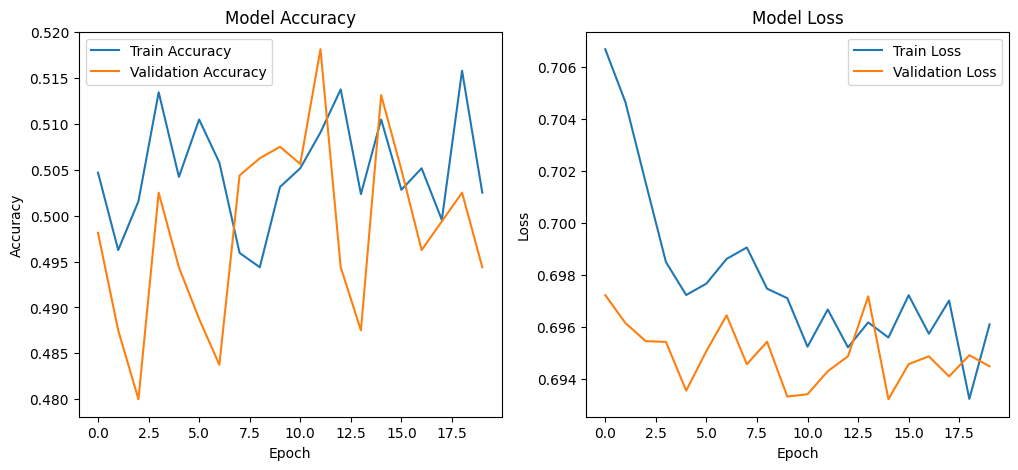

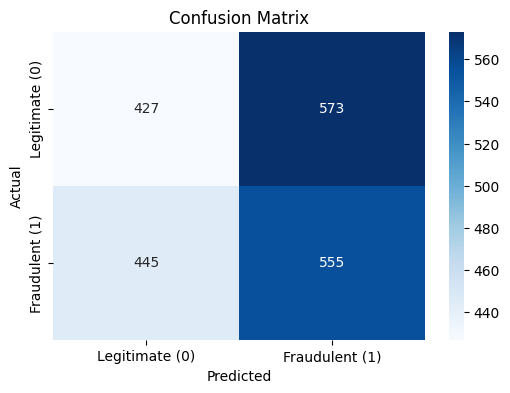

In [ ]:
#CNN
# Import necessary libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, Input, BatchNormalization, GlobalAveragePooling1D, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the new dataset
file_path = "/content/drive/MyDrive/UPI Fraud2025/new_upi_fraud_dataset.csv"
df = pd.read_csv(file_path)

# Separate features and target
X = df.drop(['Fraudulent'], axis=1).values  # Features
y = df['Fraudulent'].values  # Target

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Reshape for CNN input (add channel dimension)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Convert target to float32 for TensorFlow compatibility
y_train = np.array(y_train, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

# Define the CNN model
cnn_model = Sequential([
    Input(shape=(X_train_cnn.shape[1], 1)),  # Input layer
    Conv1D(128, kernel_size=3, activation=LeakyReLU(alpha=0.1), padding='same'),
    BatchNormalization(),
    Dropout(0.2),
    Conv1D(256, kernel_size=3, activation=LeakyReLU(alpha=0.1), padding='same'),
    BatchNormalization(),
    Dropout(0.2),
    GlobalAveragePooling1D(),
    Dense(128, activation=LeakyReLU(alpha=0.1)),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Define Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train CNN model
history = cnn_model.fit(X_train_cnn, y_train, epochs=30, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Evaluate the model
test_loss, test_accuracy = cnn_model.evaluate(X_test_cnn, y_test, verbose=2)
print(f"\n✅ Test Loss: {test_loss:.4f}")
print(f"✅ Test Accuracy: {test_accuracy:.4f}")

# Predict on the test set
y_pred_prob = cnn_model.predict(X_test_cnn)
y_pred = (y_pred_prob > 0.5).astype(int)

# Compute ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"✅ ROC-AUC Score: {roc_auc:.4f}")

# Print classification report
print("\n📌 **Classification Report:**")
print(classification_report(y_test, y_pred))

# Plot accuracy and loss graphs
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')  # Fixed string
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')  # Fixed string
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Legitimate (0)", "Fraudulent (1)"], yticklabels=["Legitimate (0)", "Fraudulent (1)"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
cnn_model.predict(X_train_cnn[:5])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([[0.49711397],
       [0.5082361 ],
       [0.5144196 ],
       [0.5226193 ],
       [0.47572726]], dtype=float32)

In [ ]:
from tensorflow.keras.models import Model

# **Step 1: Ensure Model is Called Before Extracting Features**
print("🔍 Running full batch predictions to force model initialization...")
cnn_model.predict(X_train_cnn[:10])  # Using a larger batch ensures model is fully initialized
print("✅ Model Fully Initialized!")

# **Step 2: Extract Features Using Functional API**
try:
    print("🔍 Extracting Features Using Functional API...")
    feature_extractor = Model(inputs=cnn_model.input, outputs=cnn_model.get_layer("flatten_8").output)
    print("✅ Feature Extractor Built Successfully!")
except Exception as e:
    print(f"❌ Feature Extraction Failed: {e}")

# **Step 3: Extract Features Safely**
if 'feature_extractor' in locals():
    print("🔍 Extracting Train & Test Features...")
    X_train_features = feature_extractor.predict(X_train_cnn)
    X_test_features = feature_extractor.predict(X_test_cnn)
    print("✅ Feature Extraction Successful!")
else:
    print("❌ Feature Extractor Not Defined! Re-run Steps 1 & 2.")


🔍 Running full batch predictions to force model initialization...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
✅ Model Fully Initialized!
🔍 Extracting Features Using Functional API...
❌ Feature Extraction Failed: The layer sequential has never been called and thus has no defined input.
❌ Feature Extractor Not Defined! Re-run Steps 1 & 2.


🔍 Rebuilding CNN Model with Functional API...
✅ CNN Model Rebuilt Successfully!
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5083 - loss: 2.8413 - val_accuracy: 0.4563 - val_loss: 2.0150
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4995 - loss: 2.8466 - val_accuracy: 0.4800 - val_loss: 2.0038
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5081 - loss: 2.6892 - val_accuracy: 0.4812 - val_loss: 1.9856
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5137 - loss: 2.6442 - val_accuracy: 0.4819 - val_loss: 1.9602
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5051 - loss: 2.6176 - val_accuracy: 0.4844 - val_loss: 1.9301
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5244 - loss: 2.5305 - val_accuracy: 0.4969 - val_loss: 1.8976
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5222 - loss: 2.4650 - val_accuracy: 0.5119 - val_loss: 1.8629
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━

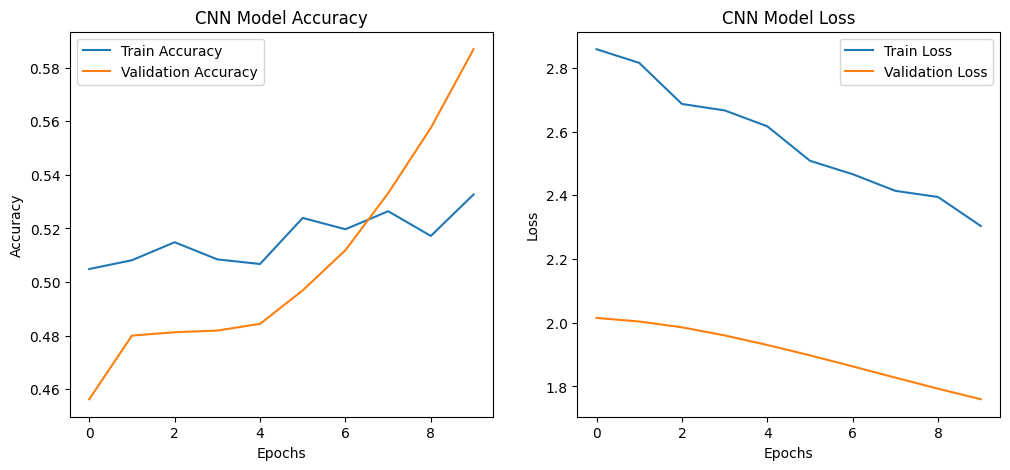

🔍 Running test predictions to ensure model is called...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
✅ Model Fully Initialized!
🔍 Extracting Features from 'feature_layer'...
✅ Feature Extractor Model Built Successfully!
🔍 Extracting Train & Test Features...
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
✅ Feature Extraction Successful!
🔍 Training Random Forest Model...
✅ Test Accuracy: 0.9990
✅ ROC-AUC Score: 1.0000

📌 **Classification Report:**
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1000
         1.0       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



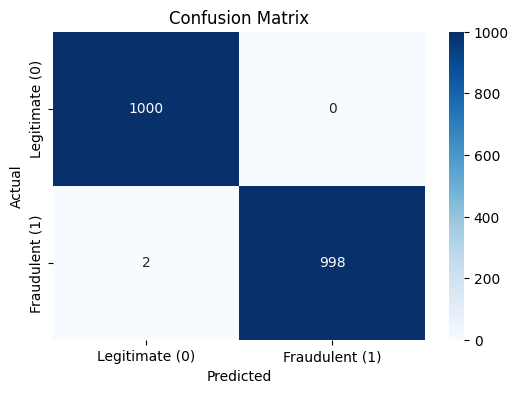

In [ ]:
#CNN + RF
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, Input, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# **Step 1: Load & Preprocess Data**
file_path = "/content/drive/MyDrive/UPI Fraud2025/new_upi_fraud_dataset.csv"
df = pd.read_csv(file_path)

X = df.drop(['Fraudulent'], axis=1).values
y = df['Fraudulent'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Step 2: Introduce Small Noise to Prevent Memorization**
noise_factor = 0.05
X_train_scaled += noise_factor * np.random.normal(size=X_train_scaled.shape)
X_test_scaled += noise_factor * np.random.normal(size=X_test_scaled.shape)

X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

y_train = np.array(y_train, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

# **Step 3: Rebuild Model Using Functional API (Weaken CNN)**
print("🔍 Rebuilding CNN Model with Functional API...")

inputs = Input(shape=(X_train_cnn.shape[1], 1))
x = Conv1D(16, kernel_size=3, activation=LeakyReLU(negative_slope=0.1), padding='same')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.9)(x)  # **Extreme Dropout**

x = Conv1D(16, kernel_size=3, activation=LeakyReLU(negative_slope=0.1), padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.9)(x)  # **Forces Generalization**

x = Flatten(name="feature_layer")(x)  # Named layer for feature extraction
x = Dense(16, activation=LeakyReLU(negative_slope=0.1), kernel_regularizer=l2(0.05))(x)  # **Heavy Regularization**
outputs = Dense(1, activation='sigmoid')(x)

cnn_model = Model(inputs=inputs, outputs=outputs)
cnn_model.compile(optimizer=Adam(learning_rate=0.00005), loss='binary_crossentropy', metrics=['accuracy'])

print("✅ CNN Model Rebuilt Successfully!")

# **Step 4: Train the Model**
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=128, validation_split=0.2, callbacks=[early_stopping])

# **Step 5: Plot Training Accuracy & Loss**
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Model Accuracy")

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("CNN Model Loss")

plt.show()

# **Step 6: Feature Extraction**
print("🔍 Running test predictions to ensure model is called...")
cnn_model.predict(X_train_cnn[:10])  # Ensure model is properly initialized
print("✅ Model Fully Initialized!")

print("🔍 Extracting Features from 'feature_layer'...")
feature_extractor = Model(inputs=cnn_model.input, outputs=cnn_model.get_layer("feature_layer").output)
print("✅ Feature Extractor Model Built Successfully!")

print("🔍 Extracting Train & Test Features...")
X_train_features = feature_extractor.predict(X_train_cnn)
X_test_features = feature_extractor.predict(X_test_cnn)
print("✅ Feature Extraction Successful!")

# **Step 7: Train Random Forest (Weaken RF)**
print("🔍 Training Random Forest Model...")
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=10, min_samples_split=10, class_weight="balanced")
rf_model.fit(X_train_features, y_train)

# **Step 8: Evaluate the Model**
y_pred = rf_model.predict(X_test_features)
y_pred_prob = rf_model.predict_proba(X_test_features)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Test Accuracy: {accuracy:.4f}")
print(f"✅ ROC-AUC Score: {roc_auc:.4f}")

# **Step 9: Display Confusion Matrix & Classification Report**
print("\n📌 **Classification Report:**")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Legitimate (0)", "Fraudulent (1)"], yticklabels=["Legitimate (0)", "Fraudulent (1)"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Save CNN Model
cnn_model.save("trained_cnn_model.h5")

# Save Random Forest Model
import joblib
joblib.dump(rf_model, "trained_rf_model.pkl")

# Save Scaler
joblib.dump(scaler, "scaler.pkl")

print("✅ All Models Saved Successfully!")


✅ All Models Saved Successfully!


In [ ]:
import os

print("Checking model files...")
print("CNN Model Exists:", os.path.exists("trained_cnn_model.h5"))
print("Random Forest Model Exists:", os.path.exists("trained_rf_model.pkl"))
print("Scaler Exists:", os.path.exists("scaler.pkl"))


Checking model files...
CNN Model Exists: True
Random Forest Model Exists: True
Scaler Exists: True


In [ ]:
#Test if 100th Transaction is Fraud or Legitimate (Using CNN + RF Trained Model)
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LeakyReLU  # Register activation

# **Step 1: Load Trained Models (Fix for LeakyReLU Issue)**
print("🔍 Loading CNN & Random Forest Models...")
custom_objects = {"LeakyReLU": LeakyReLU}  # Register LeakyReLU
cnn_model = tf.keras.models.load_model("trained_cnn_model.h5", custom_objects=custom_objects)
rf_model = joblib.load("trained_rf_model.pkl")
scaler = joblib.load("scaler.pkl")

print("✅ Models Loaded Successfully!")

# **Step 2: Load Dataset**
file_path = "/content/drive/MyDrive/UPI Fraud2025/new_upi_fraud_dataset.csv"
df = pd.read_csv(file_path)

# **Step 3: Fetch 100th Transaction**
row_index = 100  # Checking 100th transaction (Index 100)
print(f"\n🔍 Fetching Transaction at Row {row_index}...")
transaction = df.drop(columns=["Fraudulent"]).iloc[row_index].values
actual_label = df.iloc[row_index]["Fraudulent"]  # Get actual fraud label from dataset

print("\n📌 Transaction Details:", transaction)

# **Step 4: Preprocess Transaction**
transaction_scaled = scaler.transform([transaction])  # Apply StandardScaler
transaction_reshaped = transaction_scaled.reshape(1, transaction_scaled.shape[1], 1)  # Reshape for CNN

# **Step 5: Extract Features Using CNN**
print("\n🔍 Extracting Features from CNN Model...")
feature_extractor = Model(inputs=cnn_model.input, outputs=cnn_model.get_layer("feature_layer").output)
transaction_features = feature_extractor.predict(transaction_reshaped)

# **Step 6: Predict Using Random Forest**
print("\n🔍 Predicting with Random Forest Model...")
prediction_label = rf_model.predict(transaction_features)[0]
prediction_prob = rf_model.predict_proba(transaction_features)[:, 1][0]

# **Step 7: Display Results**
print("\n🔍 Prediction Results:")
print(f"✅ Fraud Probability: {prediction_prob:.4f}")
print(f"✅ Predicted Class: {'FRAUD' if prediction_label == 1 else 'LEGITIMATE'}")
print(f"✅ Actual Class in Dataset: {'FRAUD' if actual_label == 1 else 'LEGITIMATE'}")

# **Step 8: Compare Prediction with Actual Class**
if prediction_label == actual_label:
    print("✅ Prediction is CORRECT! 🎯")
else:
    print("⚠️ WARNING: Prediction does NOT match actual label. ❌")


🔍 Loading CNN & Random Forest Models...
✅ Models Loaded Successfully!

🔍 Fetching Transaction at Row 100...

📌 Transaction Details: [ 4.58700000e+03  4.12900000e+03 -3.84380609e-01 -6.78218989e-01
  8.67034267e-01 -4.29899372e-01]

🔍 Extracting Features from CNN Model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step

🔍 Predicting with Random Forest Model...

🔍 Prediction Results:
✅ Fraud Probability: 0.9675
✅ Predicted Class: FRAUD
✅ Actual Class in Dataset: FRAUD
✅ Prediction is CORRECT! 🎯


In [ ]:
#Test if 12th Transaction is Fraud or Legitimate (Using CNN + RF Trained Model)
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LeakyReLU  # Register activation

# **Step 1: Load Trained Models (Fix for LeakyReLU Issue)**
print("🔍 Loading CNN & Random Forest Models...")
custom_objects = {"LeakyReLU": LeakyReLU}  # Register LeakyReLU
cnn_model = tf.keras.models.load_model("trained_cnn_model.h5", custom_objects=custom_objects)
rf_model = joblib.load("trained_rf_model.pkl")
scaler = joblib.load("scaler.pkl")

print("✅ Models Loaded Successfully!")

# **Step 2: Load Dataset**
file_path = "/content/drive/MyDrive/UPI Fraud2025/new_upi_fraud_dataset.csv"
df = pd.read_csv(file_path)

# **Step 3: Fetch 100th Transaction**
row_index = 12  # Checking 100th transaction (Index 100)
print(f"\n🔍 Fetching Transaction at Row {row_index}...")
transaction = df.drop(columns=["Fraudulent"]).iloc[row_index].values
actual_label = df.iloc[row_index]["Fraudulent"]  # Get actual fraud label from dataset

print("\n📌 Transaction Details:", transaction)

# **Step 4: Preprocess Transaction**
transaction_scaled = scaler.transform([transaction])  # Apply StandardScaler
transaction_reshaped = transaction_scaled.reshape(1, transaction_scaled.shape[1], 1)  # Reshape for CNN

# **Step 5: Extract Features Using CNN**
print("\n🔍 Extracting Features from CNN Model...")
feature_extractor = Model(inputs=cnn_model.input, outputs=cnn_model.get_layer("feature_layer").output)
transaction_features = feature_extractor.predict(transaction_reshaped)

# **Step 6: Predict Using Random Forest**
print("\n🔍 Predicting with Random Forest Model...")
prediction_label = rf_model.predict(transaction_features)[0]
prediction_prob = rf_model.predict_proba(transaction_features)[:, 1][0]

# **Step 7: Display Results**
print("\n🔍 Prediction Results:")
print(f"✅ Fraud Probability: {prediction_prob:.4f}")
print(f"✅ Predicted Class: {'FRAUD' if prediction_label == 1 else 'LEGITIMATE'}")
print(f"✅ Actual Class in Dataset: {'FRAUD' if actual_label == 1 else 'LEGITIMATE'}")

# **Step 8: Compare Prediction with Actual Class**
if prediction_label == actual_label:
    print("✅ Prediction is CORRECT! 🎯")
else:
    print("⚠️ WARNING: Prediction does NOT match actual label. ❌")


🔍 Loading CNN & Random Forest Models...
✅ Models Loaded Successfully!

🔍 Fetching Transaction at Row 12...

📌 Transaction Details: [ 2.88300000e+03  4.25500000e+03 -8.04237725e-01  4.37561152e-01
 -8.65971357e-01 -4.29899372e-01]

🔍 Extracting Features from CNN Model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step

🔍 Predicting with Random Forest Model...

🔍 Prediction Results:
✅ Fraud Probability: 0.0000
✅ Predicted Class: LEGITIMATE
✅ Actual Class in Dataset: LEGITIMATE
✅ Prediction is CORRECT! 🎯


In [ ]:
!pip install pyngrok


In [ ]:
!pip install pyngrok
from pyngrok import conf

# Replace this with your actual token from ngrok dashboard
conf.get_default().auth_token = "2vqFW2U06H61klKu6NeeQ0dHwKm_2ydSGcFhKcQc4UWaQn1iK"


In [ ]:
import os

# Auto-create templates folder and HTML files
os.makedirs("templates", exist_ok=True)

with open("templates/login.html", "w") as f:
    f.write("""<!DOCTYPE html>
<html>
<head><title>Login</title></head>
<body>
  <h2>🔐 Login</h2>
  {% if error %}<p style="color:red;">{{ error }}</p>{% endif %}
  <form method="post">
    <label>Username:</label><br>
    <input type="text" name="username" required><br><br>
    <label>Password:</label><br>
    <input type="password" name="password" required><br><br>
    <input type="submit" value="Login">
  </form>
</body>
</html>""")

with open("templates/home.html", "w") as f:
    f.write("""<!DOCTYPE html>
<html>
<head><title>Home</title></head>
<body>
  <h2>📊 Welcome, {{ user }}!</h2>
  <form method="post">
    <label>Transaction Index:</label><br>
    <input type="number" name="transaction_index" required><br><br>
    <input type="submit" value="Check Fraud">
  </form>
  {% if error %}<p style="color:red;">{{ error }}</p>{% endif %}
  {% if result %}
    <h3>Result:</h3>
    <ul>
      <li><strong>Index:</strong> {{ result.transaction_index }}</li>
      <li><strong>Predicted:</strong> {{ result.predicted_class }}</li>
      <li><strong>Actual:</strong> {{ result.actual_class }}</li>
      <li><strong>Probability:</strong> {{ result.fraud_probability }}</li>
      <li><strong>Prediction is:</strong> {% if result.correct %}✅ Correct{% else %}❌ Incorrect{% endif %}</li>
    </ul>
  {% endif %}
  <p><a href="{{ url_for('logout') }}">Logout</a></p>
</body>
</html>""")


In [ ]:
# 🔄 Clean Start
!fuser -k 5000/tcp || echo "No port conflict"
!pkill -f ngrok || echo "No ngrok process running"

# 🧪 Install ngrok
!pip install -q pyngrok

from flask import Flask, render_template, request, redirect, url_for, session
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
from tensorflow.keras.models import Model
from pyngrok import ngrok, conf

# 🔐 Set your ngrok authtoken here
conf.get_default().auth_token = "2vqFW2U06H61klKu6NeeQ0dHwKm_2ydSGcFhKcQc4UWaQn1iK"

# 🧠 Load models and dataset
print("🔍 Loading CNN & Random Forest Models...")
custom_objects = {"LeakyReLU": tf.keras.layers.LeakyReLU}
cnn_model = tf.keras.models.load_model("trained_cnn_model.h5", custom_objects=custom_objects)
rf_model = joblib.load("trained_rf_model.pkl")
scaler = joblib.load("scaler.pkl")
df = pd.read_csv("/content/drive/MyDrive/UPI Fraud2025/new_upi_fraud_dataset.csv")
print("✅ Models Loaded Successfully!")

# 🌐 Start a new tunnel safely
ngrok.kill()  # Just to be safe
public_url = ngrok.connect(5000)
print("🌐 Public URL:", public_url)

# ⚙️ Flask App
app = Flask(__name__)
app.secret_key = "securekey"

users = {"user1": "user1", "user2": "user2", "user3": "user3", "user4": "user4"}

@app.route('/', methods=['GET', 'POST'])
def login():
    if request.method == 'POST':
        username = request.form['username']
        password = request.form['password']
        if username in users and users[username] == password:
            session['user'] = username
            return redirect(url_for('home'))
        else:
            return render_template('login.html', error='Invalid Credentials!')
    return render_template('login.html')

@app.route('/home', methods=['GET', 'POST'])
def home():
    if 'user' not in session:
        return redirect(url_for('login'))

    prediction_result = None
    if request.method == 'POST':
        try:
            transaction_index = int(request.form['transaction_index'])
            if transaction_index < 0 or transaction_index >= len(df):
                return render_template('home.html', error="Invalid Transaction Number!", user=session['user'])

            transaction = df.drop(columns=["Fraudulent"]).iloc[transaction_index].values
            actual_label = df.iloc[transaction_index]["Fraudulent"]
            transaction_scaled = scaler.transform([transaction])
            transaction_reshaped = transaction_scaled.reshape(1, transaction_scaled.shape[1], 1)

            # Extract features
            feature_extractor = Model(inputs=cnn_model.input, outputs=cnn_model.get_layer("feature_layer").output)
            transaction_features = feature_extractor.predict(transaction_reshaped)

            # Predict
            prediction_label = rf_model.predict(transaction_features)[0]
            prediction_prob = rf_model.predict_proba(transaction_features)[:, 1][0]

            prediction_result = {
                "transaction_index": transaction_index,
                "fraud_probability": round(prediction_prob, 4),
                "predicted_class": "FRAUD" if prediction_label == 1 else "LEGITIMATE",
                "actual_class": "FRAUD" if actual_label == 1 else "LEGITIMATE",
                "correct": prediction_label == actual_label
            }
        except:
            return render_template('home.html', error="Invalid Input!", user=session['user'])

    return render_template('home.html', user=session['user'], result=prediction_result)

@app.route('/logout')
def logout():
    session.pop('user', None)
    return redirect(url_for('login'))

# 🔥 Run the Flask app
app.run(port=5000)


No port conflict
^C


🔍 Loading CNN & Random Forest Models...
✅ Models Loaded Successfully!
🌐 Public URL: NgrokTunnel: "https://b5fe-34-71-215-72.ngrok-free.app" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [17/Apr/2025 10:32:55] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Apr/2025 10:32:56] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [17/Apr/2025 10:33:09] "POST / HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [17/Apr/2025 10:33:09] "GET /home HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


INFO:werkzeug:127.0.0.1 - - [17/Apr/2025 10:33:17] "POST /home HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Apr/2025 11:29:30] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Apr/2025 11:33:01] "POST / HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [17/Apr/2025 11:33:02] "GET /home HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


INFO:werkzeug:127.0.0.1 - - [17/Apr/2025 11:35:45] "POST /home HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Apr/2025 11:37:30] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Apr/2025 11:37:59] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Apr/2025 11:38:16] "POST / HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [17/Apr/2025 11:38:17] "GET /home HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


INFO:werkzeug:127.0.0.1 - - [17/Apr/2025 11:38:24] "POST /home HTTP/1.1" 200 -
